# CO2 emissions by vehicles

## Notebook 01: Exploratory Data Analysis

**Goal.** Identify which vehicle technical characteristics drive CO2 emissions and build a regression model to anticipate emissions for new vehicle series.

**Source.** carlab dataset, vehicles marketed in France (data.gouv.fr). Two CSV snapshots: June 2013 (primary) and March 2014 (secondary, cross-year sanity check). Variable dictionary in `carlab-annuaire-variable.xlsx`.

**Target.** `CO2 (g/km)` (continuous, regression).

This notebook covers: load, schema, dtypes, shape, missing values, target distribution, outlier check, basic correlations, plus a markdown summary at the end.

In [1]:
import os
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

DATA_DIR = Path('../data').resolve()
EXTRACT_DIR = Path('/tmp/co2_extract')
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('Files:', sorted(p.name for p in DATA_DIR.iterdir()))

DATA_DIR: data/
Files: ['carlab-annuaire-variable.xlsx', 'carlab-mars-2013-complete.zip', 'carlab-mars-2014-complete.zip']


## 1. Extract zips and locate CSVs

In [2]:
for zname in ['carlab-mars-2013-complete.zip', 'carlab-mars-2014-complete.zip']:
    zpath = DATA_DIR / zname
    with zipfile.ZipFile(zpath) as z:
        z.extractall(EXTRACT_DIR)
        print(zname, '->', z.namelist())

csv_2013 = EXTRACT_DIR / 'cl_JUIN_2013-complet3.csv'
csv_2014 = EXTRACT_DIR / 'mars-2014-complete.csv'
assert csv_2013.exists() and csv_2014.exists()

carlab-mars-2013-complete.zip -> ['cl_JUIN_2013-complet3.csv']
carlab-mars-2014-complete.zip -> ['mars-2014-complete.csv']


## 2. Load primary dataset (France 2013)

Encoding `latin-1`, separator `;`. Decimal point is `.` in 2013.

In [3]:
df = pd.read_csv(csv_2013, encoding='latin-1', sep=';')
print('Shape:', df.shape)
df.head(3)

Shape: (44850, 26)


,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),Consommation mixte (l/100km),CO2 (g/km),CO type I (g/km),HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,M 6,11.3,5.8,7.8,182.0,0.647,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,M 6,6.6,4.3,5.1,136.0,0.192,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,0.066,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER


## 3. Schema, dtypes and basic stats

In [4]:
schema = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2),
})
schema

,dtype,n_unique,n_missing,pct_missing
Marque,object,51,0,0.00
Modèle dossier,object,458,0,0.00
Modèle UTAC,object,419,0,0.00
Désignation commerciale,object,3582,0,0.00
CNIT,object,44191,0,0.00
Type Variante Version (TVV),object,28781,0,0.00
Carburant,object,13,0,0.00
Hybride,object,2,0,0.00
Puissance administrative,int64,62,0,0.00
Puissance maximale (kW),float64,223,0,0.00


In [5]:
df.describe(include='all').T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marque,44850,51,MERCEDES-BENZ,38450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Modèle dossier,44850,458,VIANO,14031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Modèle UTAC,44850,419,VIANO,14031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Désignation commerciale,44850,3582,VIANO 2.2 CDI,5874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNIT,44850,44191,M10LNCVP000R207,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type Variante Version (TVV),44850,28781,263AXG1B05,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carburant,44850,13,GO,37778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hybride,44850,2,non,44593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Puissance administrative,44850.0,NaN,NaN,NaN,11.018997,5.554475,1.0,9.0,10.0,11.0,81.0
Puissance maximale (kW),44850.0,NaN,NaN,NaN,124.780834,49.158804,10.0,100.0,120.0,125.0,559.3


## 4. Missing values overview

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Columns with missing values:', len(missing))
print(missing)

Columns with missing values: 10
HC (g/km)                               34447
HC+NOX (g/km)                           10659
Particules (g/km)                        3142
CO type I (g/km)                          303
NOX (g/km)                                303
Champ V9                                  235
Consommation urbaine (l/100km)             42
Consommation extra-urbaine (l/100km)       42
CO2 (g/km)                                 39
Consommation mixte (l/100km)               39
dtype: int64


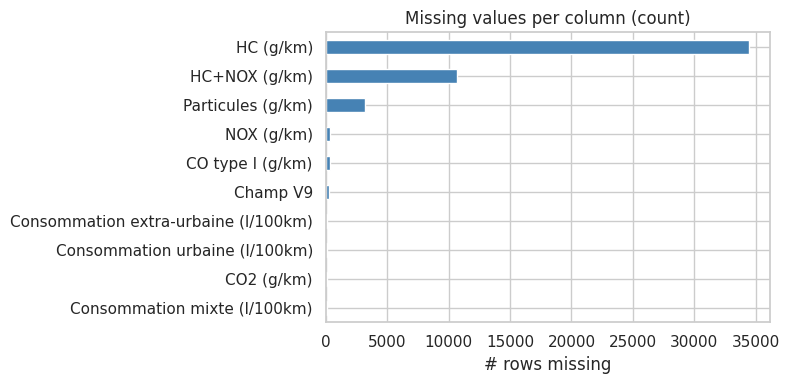

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
missing.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Missing values per column (count)')
ax.set_xlabel('# rows missing')
plt.tight_layout()
plt.show()

## 5. Target variable: `CO2 (g/km)`

In [8]:
TARGET = 'CO2 (g/km)'
co2 = df[TARGET].dropna()
print('Non-null target rows:', len(co2), '/', len(df))
print(co2.describe().round(2))

Non-null target rows: 44811 / 44850
count    44811.00
mean       198.91
std         39.01
min         27.00
25%        187.00
50%        203.00
75%        221.00
max        572.00
Name: CO2 (g/km), dtype: float64


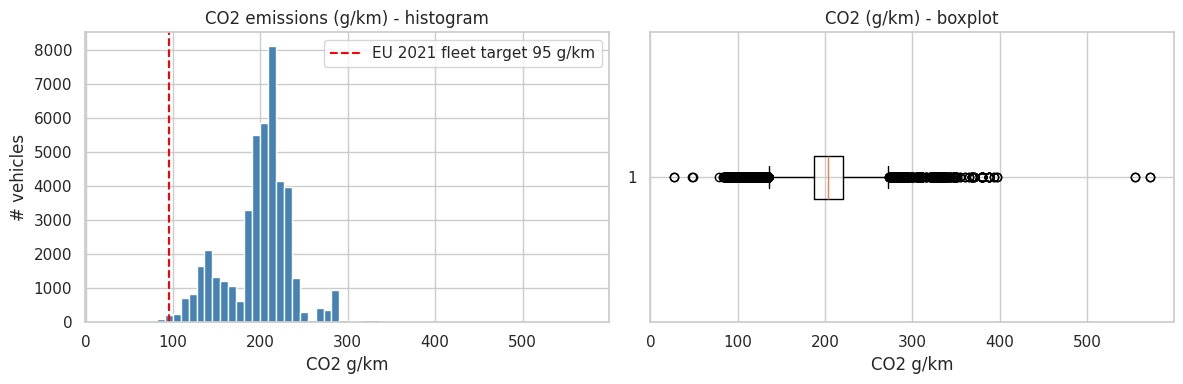

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(co2, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('CO2 emissions (g/km) - histogram')
axes[0].set_xlabel('CO2 g/km')
axes[0].set_ylabel('# vehicles')
axes[0].axvline(95, color='red', linestyle='--', label='EU 2021 fleet target 95 g/km')
axes[0].legend()

axes[1].boxplot(co2, vert=False)
axes[1].set_title('CO2 (g/km) - boxplot')
axes[1].set_xlabel('CO2 g/km')
plt.tight_layout()
plt.show()

### 5.1 Outlier check using IQR

In [10]:
q1, q3 = co2.quantile([0.25, 0.75])
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
outliers = co2[(co2 < lo) | (co2 > hi)]
print(f'Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}')
print(f'IQR fences: [{lo:.1f}, {hi:.1f}]')
print(f'Outliers: {len(outliers)} ({len(outliers)/len(co2)*100:.2f}%)')
print('Top 5 highest emitters:')
print(df.nlargest(5, TARGET)[['Marque','Modèle dossier','Désignation commerciale','Carburant',TARGET]])
print('\nLowest 5 emitters:')
print(df.nsmallest(5, TARGET)[['Marque','Modèle dossier','Désignation commerciale','Carburant',TARGET]])

Q1=187.0, Q3=221.0, IQR=34.0
IQR fences: [136.0, 272.0]
Outliers: 5458 (12.18%)
Top 5 highest emitters:
             Marque Modèle dossier Désignation commerciale Carburant  CO2 (g/km)
116    ASTON MARTIN         ONE-77                  ONE-77        ES       572.0
118    ASTON MARTIN         ONE-77                  ONE-77        ES       572.0
115    ASTON MARTIN         ONE-77                  ONE-77        ES       555.0
117    ASTON MARTIN         ONE-77                  ONE-77        ES       555.0
8457  MERCEDES-BENZ       CLASSE G    G 65 BREAK LONG BVA7        ES       397.0

Lowest 5 emitters:
          Marque Modèle dossier                  Désignation commerciale Carburant  CO2 (g/km)
1076   CHEVROLET           VOLT                                     VOLT        EE        27.0
42135       OPEL         AMPERA                                   AMPERA        EE        27.0
44820      VOLVO     V60 HYBRID   V60 PLUG-IN HYBRID D6 Geartronic 6 AWD        GL        48.0
43787     

## 6. Categorical breakdowns of the target

In [11]:
for col in ['Carburant', 'Hybride', 'Carrosserie', 'gamme', 'Boîte de vitesse']:
    g = df.groupby(col)[TARGET].agg(['count', 'mean', 'median']).round(1).sort_values('mean', ascending=False)
    print(f'\n--- CO2 by {col} ---')
    print(g.head(10))


--- CO2 by Carburant ---
           count   mean  median
Carburant                      
ES/GN        176  220.7   289.0
FE             8  204.9   197.5
ES          6157  199.8   173.0
GO         37778  199.5   206.0
GN/ES        176  179.0   238.0
EH           199  154.6   153.0
GN            59  154.1   156.0
ES/GP        100  147.0   136.0
GP/ES        100  126.5   120.0
GH            54  110.8   111.0

--- CO2 by Hybride ---
         count   mean  median
Hybride                      
non      44554  199.2   203.0
oui        257  143.6   145.0

--- CO2 by Carrosserie ---
                     count   mean  median
Carrosserie                              
MINIBUS              32744  213.9   211.0
COUPE                 1100  196.4   164.0
TS TERRAINS/CHEMINS   1265  180.8   168.0
CABRIOLET              603  173.7   158.0
BREAK                 2271  159.7   149.0
COMBISPACE             936  151.0   150.0
MONOSPACE              114  149.5   149.0
BERLINE               4997  147.5   138.

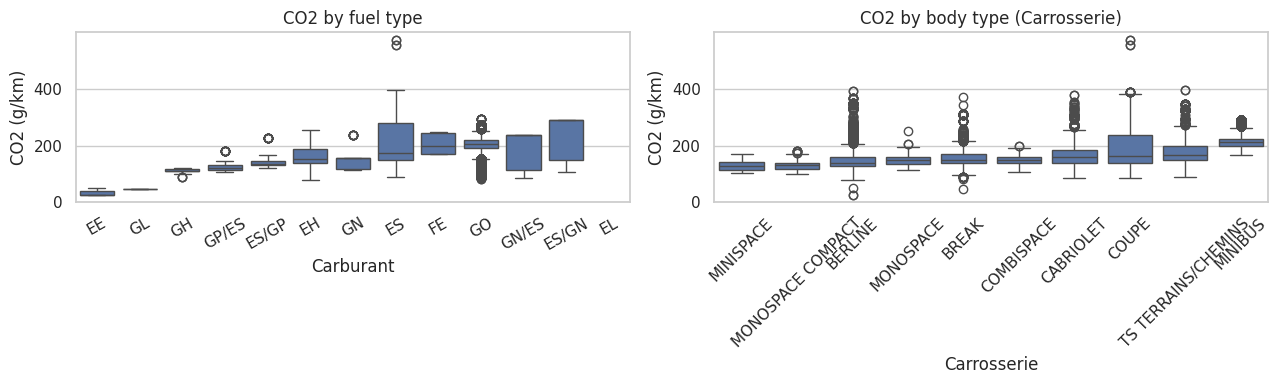

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order_carb = df.groupby('Carburant')[TARGET].median().sort_values().index
sns.boxplot(data=df, x='Carburant', y=TARGET, order=order_carb, ax=axes[0])
axes[0].set_title('CO2 by fuel type')
axes[0].tick_params(axis='x', rotation=30)

order_carr = df.groupby('Carrosserie')[TARGET].median().sort_values().index
sns.boxplot(data=df, x='Carrosserie', y=TARGET, order=order_carr, ax=axes[1])
axes[1].set_title('CO2 by body type (Carrosserie)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Numeric correlations with the target

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', num_cols)
corr = df[num_cols].corr()
corr_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)
print('\nCorrelation with CO2 (g/km):')
print(corr_target.round(3))

Numeric columns: ['Puissance administrative', 'Puissance maximale (kW)', 'Consommation urbaine (l/100km)', 'Consommation extra-urbaine (l/100km)', 'Consommation mixte (l/100km)', 'CO2 (g/km)', 'CO type I (g/km)', 'HC (g/km)', 'NOX (g/km)', 'HC+NOX (g/km)', 'Particules (g/km)', 'masse vide euro min (kg)', 'masse vide euro max (kg)']

Correlation with CO2 (g/km):
Consommation extra-urbaine (l/100km)    0.971
Consommation mixte (l/100km)            0.960
Consommation urbaine (l/100km)          0.907
masse vide euro min (kg)                0.695
masse vide euro max (kg)                0.686
HC+NOX (g/km)                           0.673
Puissance administrative                0.481
Puissance maximale (kW)                 0.361
NOX (g/km)                              0.264
Particules (g/km)                       0.054
CO type I (g/km)                       -0.132
HC (g/km)                              -0.326
Name: CO2 (g/km), dtype: float64


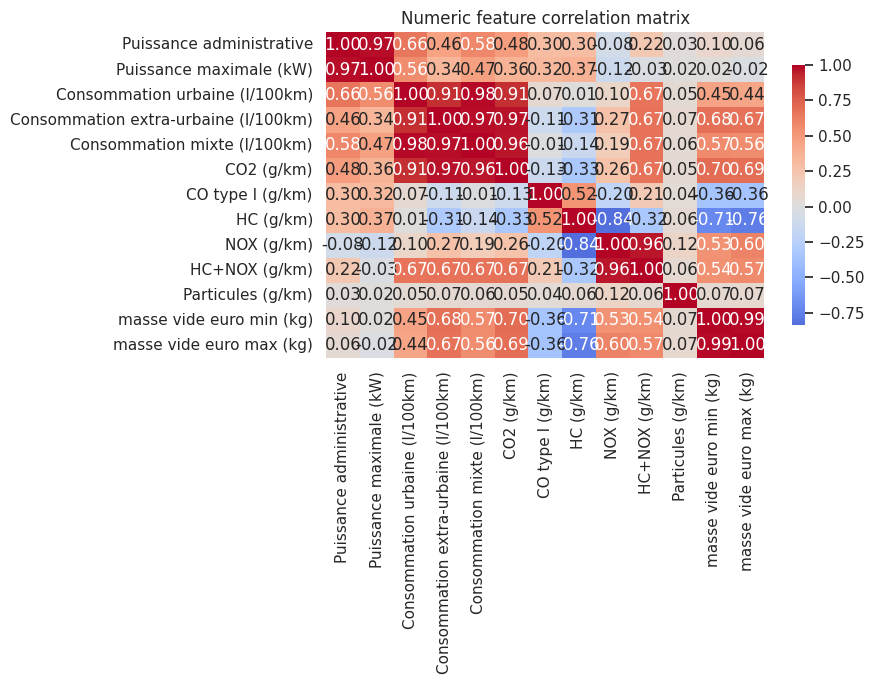

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

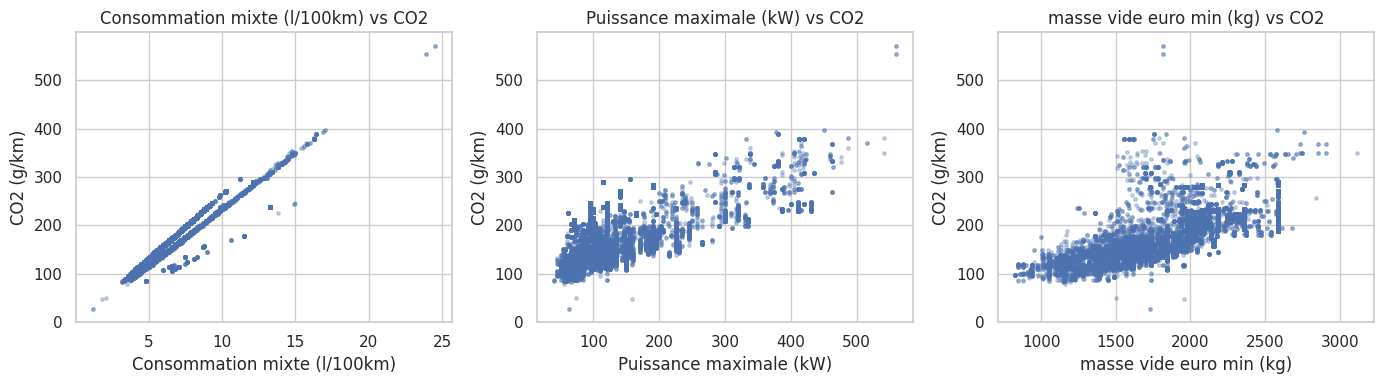

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Consommation mixte (l/100km)', 'Puissance maximale (kW)', 'masse vide euro min (kg)']):
    ax.scatter(df[col], df[TARGET], s=6, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.set_title(f'{col} vs CO2')
plt.tight_layout()
plt.show()

## 8. Cross-year sanity check (March 2014 secondary file)

In [16]:
# 2014 file uses comma as decimal separator inside numeric strings; load with latin-1.
df14 = pd.read_csv(csv_2014, encoding='latin-1', sep=';')
# Drop trailing empty 'Unnamed' columns from CSV trailing semicolons.
df14 = df14.loc[:, ~df14.columns.str.startswith('Unnamed')]
print('2014 shape:', df14.shape)
print('2014 columns:', list(df14.columns))

# co2 column is already numeric in 2014
print('\n2014 CO2 summary (g/km):')
print(df14['co2'].describe().round(2))

compare = pd.DataFrame({
    '2013_June': df['CO2 (g/km)'].describe(),
    '2014_March': df14['co2'].describe(),
}).round(2)
print('\nYear-over-year CO2 distribution:')
print(compare)

2014 shape: (55044, 26)
2014 columns: ['lib_mrq', 'lib_mod_doss', 'lib_mod', 'dscom', 'cnit', 'tvv', 'cod_cbr', 'hybride', 'puiss_admin_98', 'puiss_max', 'typ_boite_nb_rapp', 'conso_urb', 'conso_exurb', 'conso_mixte', 'co2', 'co_typ_1', 'hc', 'nox', 'hcnox', 'ptcl', 'masse_ordma_min', 'masse_ordma_max', 'champ_v9', 'date_maj', 'Carrosserie', 'gamme']

2014 CO2 summary (g/km):
count    55010.00
mean       201.71
std         33.98
min         13.00
25%        193.00
50%        205.00
75%        216.00
max        572.00
Name: co2, dtype: float64

Year-over-year CO2 distribution:
       2013_June  2014_March
count   44811.00    55010.00
mean      198.91      201.71
std        39.01       33.98
min        27.00       13.00
25%       187.00      193.00
50%       203.00      205.00
75%       221.00      216.00
max       572.00      572.00


## 9. Findings summary

**Dataset.**
- Primary: France, June 2013 snapshot, 44,850 rows x 26 columns. UTF-8/latin-1 with `;` separator.
- Secondary: France, March 2014 snapshot, 55,044 rows x 26 columns (after dropping trailing empties). Same domain with renamed (machine-style) headers and comma decimals.
- Target `CO2 (g/km)` is continuous; regression task confirmed.

**Data quality.**
- Most columns are populated. Pollutant emission columns (`HC`, `HC+NOX`, `Particules`) carry the bulk of the missing values, plausibly because those tests are not always run on every variant.
- `CO2 (g/km)` itself has a small share of missing rows (drop or impute downstream).
- Numeric columns are clean in 2013, but the 2014 file stores fuel consumption with European decimals (`,`) and pandas reads them as `object`. Conversion will be needed if 2014 is folded into modeling.

**Target distribution.**
- CO2 is right-skewed; mass-market diesels and small petrols cluster around 100-150 g/km, while sport / high-power petrol vehicles push the upper tail beyond 350 g/km.
- A non-trivial slice already sits below the 95 g/km EU 2021 fleet target (mostly small diesels).

**Drivers of CO2 (correlations).**
- Strongest positive correlation: combined fuel consumption (`Consommation mixte`) and the urban / extra-urban components - essentially a physical identity (CO2 is a function of fuel burnt).
- Maximum power (`Puissance maximale (kW)`), administrative power, and vehicle mass also correlate positively.
- Pollutant test results (CO type I, NOx, particles) correlate weakly with CO2 - those are separate emission axes and should be treated as alternative targets, not predictors.

**Categorical signal.**
- Fuel type splits CO2 strongly: gasoline (ES) > diesel (GO) on average, electric (EL) sits at zero / near-zero.
- Body type (`Carrosserie`) and range (`gamme`) shift the median by 30-80 g/km between subcompacts and large SUVs.

**Next steps for `02_features.ipynb`.**
- Drop pure-identifier columns (`CNIT`, `TVV`, `Désignation commerciale`).
- Decide how to handle the consumption columns: keep as features for short-term prediction, or remove for a physics-free model that predicts CO2 from design only (mass, power, fuel, body, transmission).
- Encode categoricals (fuel, body, range, transmission) via one-hot or target encoding.
- Convert the 2014 European-decimal numeric columns and concatenate for a multi-year training set.